In K-Nearest Neighbors (KNN), model complexity and fit are primarily controlled by the hyperparameter \(K\) (the number of neighbors).


1. Model Complexity vs. \(K\) ValueThe complexity of a KNN model is inversely proportional to \(K\).

 Low \(K\) (High Complexity): The model captures local details and noise, leading to "jagged" decision boundaries. 

 
 High \(K\) (Low Complexity): The model averages predictions over many neighbors, resulting in "smoother" decision boundaries

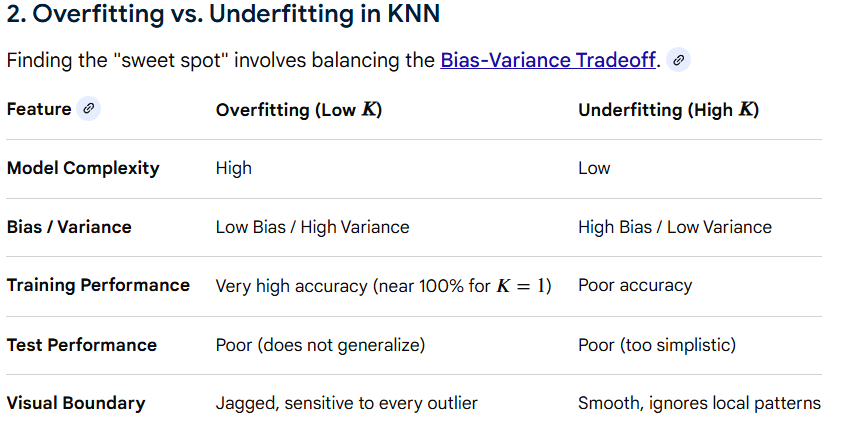

In [7]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt

In [6]:
# !pip3 install scikit-learn
# !pip3 install matplotlib

In [10]:
# Load dataset (Replace with your own X, y if available)
data = load_iris()
# print(data)
X = data.data
y = data.target

In [12]:
# print(X)

In [16]:
# 1. Splitting data to detect overfitting/underfitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((105, 4), (45, 4), (105,), (45,))

In [19]:
# 2. Testing different K values
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Using cross-validation for stable accuracy estimate
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    # print(f"K={k}, CV Scores: {scores}, Mean CV Score: {scores.mean()}")
    cv_scores.append(scores.mean())

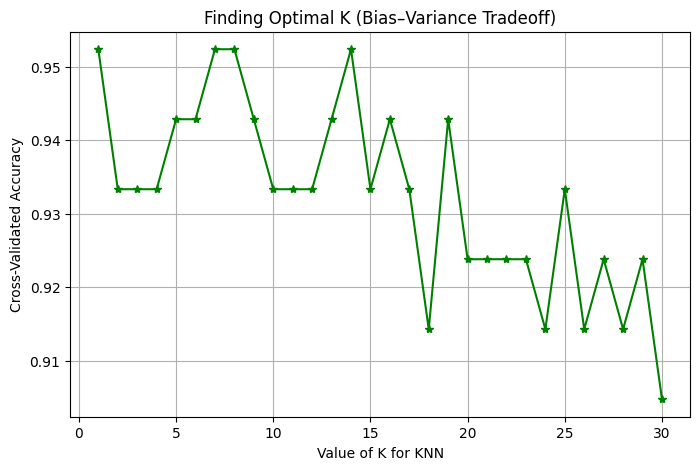

In [23]:
# 3. Visualizing the 'Sweet Spot'
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='*',color = 'green')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding Optimal K (Bias–Variance Tradeoff)')
plt.grid(True)
plt.show()

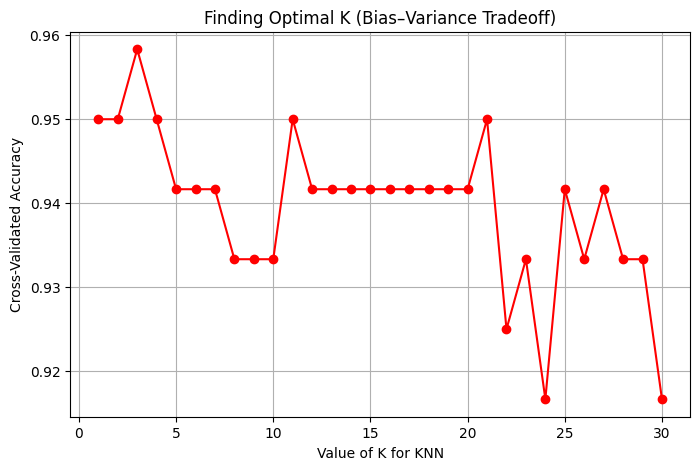

In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt

# Load dataset (Replace with your own X, y if available)
data = load_iris()
X = data.data
y = data.target

# 1. Splitting data to detect overfitting/underfitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 2. Testing different K values
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Using cross-validation for stable accuracy estimate
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

# 3. Visualizing the 'Sweet Spot'
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o',color = 'red')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding Optimal K (Bias–Variance Tradeoff)')
plt.grid(True)
plt.show()

In [2]:
optimal_k = k_range[cv_scores.index(max(cv_scores))]
print("Optimal K =", optimal_k)

Optimal K = 3


\(K=1\) is most complex: It will perfectly predict training data but fail on new data because it follows noise.\(K = N\) (total samples) is least complex: It will simply predict the majority class for every input, ignoring all features.Optimization: Use the scikit-learn GridSearchCV to automate finding the \(K\) value that minimizes both training and test error